In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
months = ["jan24", "feb24", "mar24", "apr24","may24", "jun24", 
          "jul24", "aug24","sep24", "oct24", "nov24", "dec24"]

df24 = pd.concat((pd.read_csv(f"../data/{m}.csv") for m in months),ignore_index=True)

C:\Users\divya\AppData\Local\Temp\ipykernel_16956\788946992.py:4: DtypeWarning: Columns (30) have mixed types. Specify dtype option on import or set low_memory=False.
  df24 = pd.concat((pd.read_csv(f"../data/{m}.csv") for m in months),ignore_index=True)
C:\Users\divya\AppData\Local\Temp\ipykernel_16956\788946992.py:4: DtypeWarning: Columns (30) have mixed types. Specify dtype option on import or set low_memory=False.
  df24 = pd.concat((pd.read_csv(f"../data/{m}.csv") for m in months),ignore_index=True)


In [3]:
df24["FL_DATE"] = pd.to_datetime(df24["FL_DATE"], errors="coerce")
df24 = df24.dropna(subset=["FL_DATE"]).copy()
df24["date"] = df24["FL_DATE"].dt.date

crs = pd.to_numeric(df24["CRS_DEP_TIME"], errors="coerce").fillna(0).astype(int)
df24["dep_hour"] = (crs // 100).clip(0, 23).astype(int)

df24["airport_key"] = df24["ORIGIN"].astype(str).str.upper().str.strip()

C:\Users\divya\AppData\Local\Temp\ipykernel_16956\4142822563.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df24["FL_DATE"] = pd.to_datetime(df24["FL_DATE"], errors="coerce")


In [4]:
# Cancelled / Diverted / Delayed / On Time
df24["cancelled"] = df24["CANCELLED"].fillna(0).astype(int) == 1
df24["diverted"]  = df24["DIVERTED"].fillna(0).astype(int) == 1
df24["operated"]  = (~df24["cancelled"]) & (~df24["diverted"])

df24["DEP_DELAY"] = pd.to_numeric(df24["DEP_DELAY"], errors="coerce")
df24["ARR_DELAY"] = pd.to_numeric(df24["ARR_DELAY"], errors="coerce")

df24["arr_delayed"] = df24["operated"] & (df24["ARR_DELAY"] > 15)
df24["on_time"]     = df24["operated"] & (~df24["arr_delayed"])

df24["outcome"] = np.select(
    [df24["cancelled"], df24["diverted"], df24["arr_delayed"], df24["on_time"]],
    ["Cancelled", "Diverted", "Delayed", "On Time"],default="Unknown")
df24["outcome"].value_counts()

outcome
On Time      5561879
Delayed      1403388
Cancelled      96315
Diverted       17499
Name: count, dtype: int64

In [5]:
city = ["ATL","DEN","DFW","CLT","JFK","LAX","ORD","PHX","LAS","SEA","LGA"]
# Load  weather data
weather = pd.concat((pd.read_csv(f"../data/{c}.csv") for c in city),ignore_index=True)

In [6]:
weather.head()

,station,valid,lon,lat,elevation,tmpf,dwpf,relh,drct,sknt,...,wxcodes,ice_accretion_1hr,ice_accretion_3hr,ice_accretion_6hr,peak_wind_gust,peak_wind_drct,peak_wind_time,feel,metar,snowdepth
0,ATL,2024-01-01 00:52,-84.4418,33.6301,315.0,48.0,32.0,53.67,220.00,5.00,...,M,M,M,M,M,M,M,45.4,KATL 010052Z 22005KT 10SM FEW250 09/00 A3011 R...,M
1,ATL,2024-01-01 01:52,-84.4418,33.6301,315.0,46.0,32.0,57.87,250.00,4.00,...,M,M,M,M,M,M,M,43.77,KATL 010152Z 25004KT 10SM SCT250 08/00 A3012 R...,M
2,ATL,2024-01-01 02:52,-84.4418,33.6301,315.0,46.0,32.0,57.87,230.00,5.00,...,M,M,M,M,M,M,M,43.02,KATL 010252Z 23005KT 10SM SCT200 BKN220 08/00 ...,M
3,ATL,2024-01-01 03:52,-84.4418,33.6301,315.0,46.0,32.0,57.87,250.00,5.00,...,M,M,M,M,M,M,M,43.02,KATL 010352Z 25005KT 10SM BKN220 BKN250 08/00 ...,M
4,ATL,2024-01-01 04:52,-84.4418,33.6301,315.0,45.0,32.0,60.11,240.00,4.00,...,M,M,M,M,M,M,M,42.6,KATL 010452Z 24004KT 10SM BKN220 BKN250 07/00 ...,M


In [7]:
# Rename only what we need (adjust if column names differ)
weather = weather.rename(columns={"valid": "datetime","station": "airport","tmpf": "temp_f",
    "sknt": "wind_kt","vsby": "visibility_mi","p01i": "precip_in"})
weather["airport_key"] = weather["airport"].astype(str).str.upper().str.strip()

In [8]:
# Datetime
weather["datetime_utc"] = pd.to_datetime(weather["datetime"], errors="coerce", utc=True)
weather = weather.dropna(subset=["datetime_utc"]).copy()

airport_tz = {"JFK": "America/New_York","ATL": "America/New_York","ORD": "America/Chicago",
    "DFW": "America/Chicago","DEN": "America/Denver","LAX": "America/Los_Angeles",}
weather["tz"] = weather["airport_key"].map(airport_tz)

# Convert UTC -> local
weather["datetime_local"] = weather.apply(
    lambda r: r["datetime_utc"].tz_convert(r["tz"]) if pd.notna(r["tz"]) else pd.NaT,axis=1)
weather = weather.dropna(subset=["datetime_local"]).copy()

# datetime dtype
weather["datetime_local"] = pd.to_datetime(weather["datetime_local"], errors="coerce")
weather = weather.dropna(subset=["datetime_local"]).copy()

weather["date"] = weather["datetime_local"].dt.date
weather["hour"] = weather["datetime_local"].dt.hour

In [9]:
for c in ["precip_in", "visibility_mi", "wind_kt", "temp_f"]:
    weather[c] = pd.to_numeric(weather[c], errors="coerce")
    
weather["precip_event"] = weather["precip_in"].fillna(0) > 0
weather["low_visibility"] = weather["visibility_mi"] < 3
weather["high_wind"] = weather["wind_kt"] > 30

# Snow & rain 
weather["snow_event"] = (weather["precip_event"]) & (weather["temp_f"] <= 34)
weather["rain_event"] = (weather["precip_event"]) & (weather["temp_f"] > 34)

In [10]:
weather_df = weather[[ "airport_key", "date", "hour",
        "temp_f", "wind_kt", "visibility_mi",
        "precip_event", "low_visibility", "high_wind",
        "snow_event", "rain_event"]].copy()

In [11]:
# merge keys
df24["date"] = pd.to_datetime(df24["date"], errors="coerce").dt.date
weather_df["date"] = pd.to_datetime(weather_df["date"], errors="coerce").dt.date

df24["dep_hour"] = pd.to_numeric(df24["dep_hour"], errors="coerce").astype("Int64")
weather_df["hour"] = pd.to_numeric(weather_df["hour"], errors="coerce").astype("Int64")

df24["airport_key"] = df24["airport_key"].astype(str).str.upper().str.strip()
weather_df["airport_key"] = weather_df["airport_key"].astype(str).str.upper().str.strip()

In [12]:
#  Merge flights and weather
merged_df = df24.merge(weather_df,left_on=["airport_key", "date", "dep_hour"],
    right_on=["airport_key", "date", "hour"],how="left")
merged_df["has_weather"] = merged_df["precip_event"].notna()

In [13]:
df_w = merged_df[merged_df["has_weather"]].copy()

In [14]:
df_w["weather_type"] = "Clear"
df_w.loc[df_w["rain_event"], "weather_type"] = "Rain"
df_w.loc[df_w["snow_event"], "weather_type"] = "Snow"
df_w["disrupted"] = df_w["outcome"].isin(["Delayed", "Cancelled", "Diverted"])

In [15]:
outcome_mix = (df_w.groupby(["weather_type", "outcome"])
    .size().reset_index(name="count"))

outcome_mix["share"] = (outcome_mix
    .groupby("weather_type")["count"].transform(lambda x: x / x.sum()))

outcome_mix = outcome_mix.drop(columns="count")

In [16]:
table = (outcome_mix.pivot(index="weather_type", columns="outcome", values="share")
        .reindex(["Clear", "Rain", "Snow"]).reset_index())

for col in ["On Time", "Delayed", "Cancelled", "Diverted"]:
    if col not in table.columns:
        table[col] = 0.0

# Convert to percentages
table.iloc[:, 1:] = table.iloc[:, 1:] * 100
table = table.round(2)

table = table[["weather_type", "On Time", "Delayed", "Cancelled", "Diverted"]]
table

outcome,weather_type,On Time,Delayed,Cancelled,Diverted
0,Clear,79.61,18.96,1.19,0.24
1,Rain,56.99,39.53,3.16,0.32
2,Snow,10.77,71.67,17.15,0.41


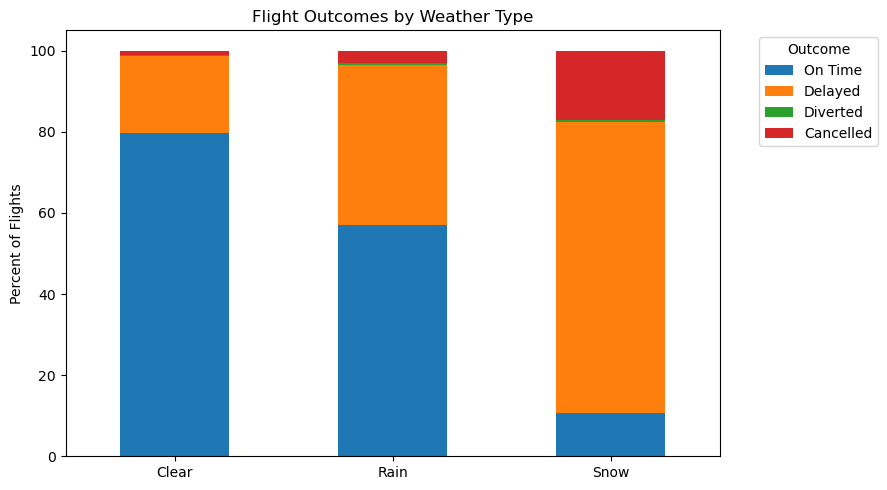

In [17]:
plot_pivot = table.set_index("weather_type")[["On Time", "Delayed","Diverted", "Cancelled"]]
plot_pivot.plot(kind="bar", stacked=True, figsize=(9,5),linewidth=0.6)
plt.title("Flight Outcomes by Weather Type")
plt.xlabel("")
plt.ylabel("Percent of Flights")
plt.xticks(rotation=0)
plt.legend(title="Outcome", bbox_to_anchor=(1.05,1), loc="upper left")
plt.tight_layout()
plt.savefig('../charts/flights_by_weather.png', dpi=300,bbox_inches="tight")
plt.show()

In [18]:
# Extreme delay risk (>60 min)
df_w["delay_60+"] = df_w["operated"] & (df_w["ARR_DELAY"] >= 60)

df_w.groupby("weather_type")["delay_60+"].mean()

weather_type
Clear    0.066012
Rain     0.188762
Snow     0.449047
Name: delay_60+, dtype: float64

In [19]:
df_w["month"] = pd.to_datetime(df_w["date"]).dt.month
month_w = (df_w.groupby(["month", "weather_type"]).agg(cancel_rate=("cancelled", "mean"),
        avg_delay=("ARR_DELAY", "mean")).reset_index())

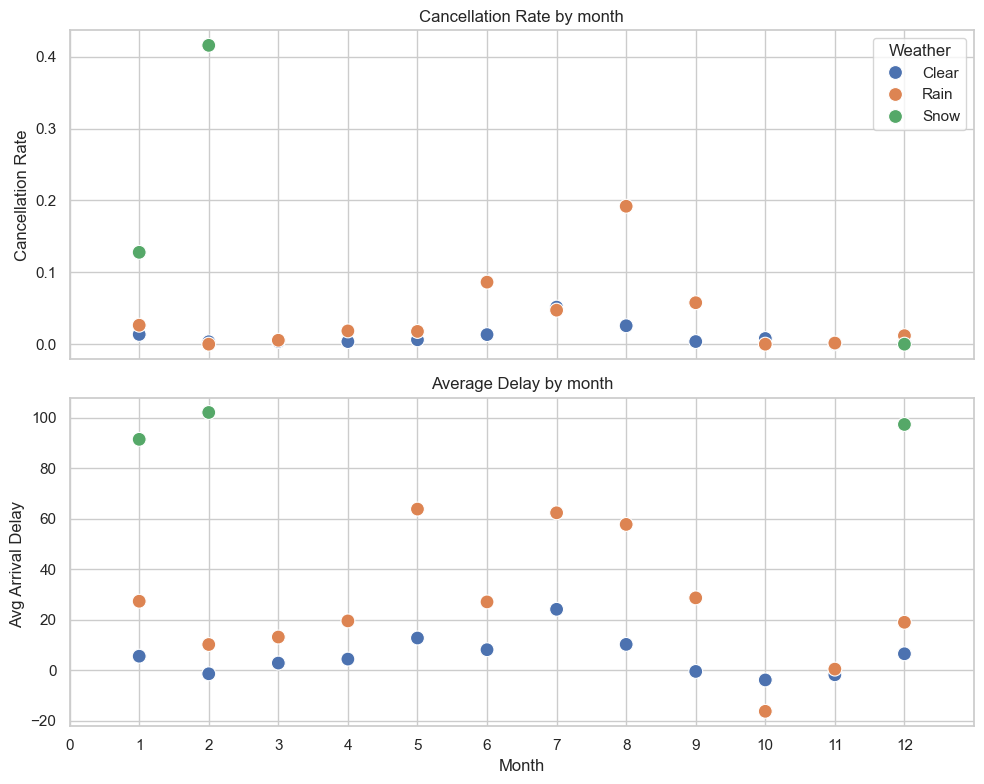

In [20]:
sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(nrows=2,ncols=1,figsize=(10, 8),sharex=True)

# --- Cancellation rate ---
sns.scatterplot(data=month_w,x="month",y="cancel_rate",hue="weather_type",ax=axes[0],marker="o",s=100)

axes[0].set_title("Cancellation Rate by month")
axes[0].set_ylabel("Cancellation Rate")
axes[0].legend(title="Weather")

# --- Arrival delay ---
sns.scatterplot(data=month_w,x="month",y="avg_delay",hue="weather_type",ax=axes[1],marker="o",s=100,legend=False)

axes[1].set_title("Average Delay by month")
axes[1].set_ylabel("Avg Arrival Delay ")
axes[1].set_xlabel("Month")

# --- X-axis ticks every 4 hours ---
axes[1].set_xticks(range(0, 13, 1))
axes[1].set_xlim(0, 13)

plt.tight_layout()
plt.savefig('../charts/weatherimpact_month.png', dpi=300,bbox_inches="tight")
plt.show()

In [21]:
outcome = (df_w
    .groupby(["precip_event", "outcome"]).size().groupby(level=0, group_keys=False)
    .apply(lambda x: x / x.sum()).reset_index(name="share"))
outcome

,precip_event,outcome,share
0,False,Cancelled,0.011921
1,False,Delayed,0.189555
2,False,Diverted,0.002414
3,False,On Time,0.796110
4,True,Cancelled,0.034960
5,True,Delayed,0.402971
6,True,Diverted,0.003219
7,True,On Time,0.558850


In [22]:
# Weather severity → cancellation risk (simple, powerful)
severity_cancel = (
    df_w
    .groupby(["low_visibility", "high_wind"])
    .agg(cancel_rate=("cancelled", "mean")
    ).sort_values("cancel_rate", ascending=False)
)
severity_cancel

,,cancel_rate
low_visibility,high_wind,
True,True,0.080000
False,True,0.028571
True,False,0.019019
False,False,0.013699


In [23]:
pre = (df_w
    .groupby([ "precip_event"]).agg(
        avg_arr_delay=("ARR_DELAY", "mean"),
        flights=("ARR_DELAY", "size")).reset_index()
)
pre.head()

,precip_event,avg_arr_delay,flights
0,False,5.865058,484672
1,True,30.728335,50629


In [30]:
df_w = merged_df[merged_df["has_weather"]].copy()
df_w["snow_event"] = df_w["snow_event"].fillna(False).astype(bool)

# Snow vs non-snow
df_w["snow_only"] = df_w["snow_event"]

snow_outcomes = (df_w.groupby("snow_only").agg(cancel_rate=("cancelled", "mean"),
        divert_rate=("diverted", "mean"),operated_rate=("operated", "mean")))
snow_outcomes

C:\Users\divya\AppData\Local\Temp\ipykernel_16956\2780669829.py:2: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_w["snow_event"] = df_w["snow_event"].fillna(False).astype(bool)


,cancel_rate,divert_rate,operated_rate
snow_only,,,
False,0.013745,0.002486,0.983769
True,0.171500,0.004143,0.824358


In [26]:
""" hourly_delay = (df_w[df_w["operated"]]
    .dropna(subset=["ARR_DELAY"])
    .groupby(["dep_hour", "weather_type"])
    .agg(avg_arr_delay=("ARR_DELAY", "mean"),
        flights=("ARR_DELAY", "size")).reset_index())

plt.figure(figsize=(10,5))
for wt in ["Clear", "Rain", "Snow"]:
    sub = hourly_delay[hourly_delay["weather_type"] == wt].sort_values("dep_hour")
    plt.plot(sub["dep_hour"], sub["avg_arr_delay"], marker="o", label=wt)

plt.title("Average Arrival Delay by Scheduled Departure Hour (Operated Flights)")
plt.xlabel("Scheduled Departure Hour")
plt.ylabel("Avg Arrival Delay (minutes)")
plt.xticks(range(0, 24, 2))
plt.legend(title="Weather Type")
plt.tight_layout()
plt.show()"""

' hourly_delay = (df_w[df_w["operated"]]\n    .dropna(subset=["ARR_DELAY"])\n    .groupby(["dep_hour", "weather_type"])\n    .agg(avg_arr_delay=("ARR_DELAY", "mean"),\n        flights=("ARR_DELAY", "size")).reset_index())\n\nplt.figure(figsize=(10,5))\nfor wt in ["Clear", "Rain", "Snow"]:\n    sub = hourly_delay[hourly_delay["weather_type"] == wt].sort_values("dep_hour")\n    plt.plot(sub["dep_hour"], sub["avg_arr_delay"], marker="o", label=wt)\n\nplt.title("Average Arrival Delay by Scheduled Departure Hour (Operated Flights)")\nplt.xlabel("Scheduled Departure Hour")\nplt.ylabel("Avg Arrival Delay (minutes)")\nplt.xticks(range(0, 24, 2))\nplt.legend(title="Weather Type")\nplt.tight_layout()\nplt.show()'

In [28]:
def time_of_day_bucket(h):
    if h < 6:
        return "Overnight (12 AM–6 AM)"
    elif h < 12:
        return "Morning (6 AM–12 PM)"
    elif h < 18:
        return "Afternoon (12–6 PM)"
    else:
        return "Evening (6 PM–12 AM)"

df_w["time_of_day"] = df_w["dep_hour"].apply(time_of_day_bucket)

df_w["time_of_day"].value_counts()


time_of_day
Morning (6 AM–12 PM)      202198
Afternoon (12–6 PM)       180690
Evening (6 PM–12 AM)      148919
Overnight (12 AM–6 AM)      3494
Name: count, dtype: int64

In [29]:
# Compare cancellation vs delay by time of day for snow only
snow_tod = (
    df_w[df_w["precip_event"]]
    .groupby("time_of_day")
    .agg(
        cancel_rate=("cancelled", "mean"),
        delay_rate=("arr_delayed", "mean")
    )
)
snow_tod

,cancel_rate,delay_rate
time_of_day,,
Afternoon (12–6 PM),0.027854,0.381910
Evening (6 PM–12 AM),0.061695,0.501701
Morning (6 AM–12 PM),0.019523,0.347124
Overnight (12 AM–6 AM),0.057927,0.161585
